# Final Plots for the Kinectic Misalignment Project

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os,sys
import json

import pickle
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.collections import LineCollection
import matplotlib.patheffects as path_effects

# Helper function to create a line outline effect
def line_background(linewidth=1.5, color='k'):
    return [path_effects.Stroke(linewidth=linewidth, foreground=color),
            path_effects.Normal()]

from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

plt.style.use('paper.mplstyle') 
plt.rcParams["text.usetex"] = True

sys.path.append('../tools/')
sys.path.append('/Users/Mathieu/Salsa/jaxionsdir/jaxions/scripts/') #adapt to your JAXIONS_DIR

# Kinetic misalignment functions
from kin_mis_utils import (evolution_kinetic_mis, genspec_kinetic_mis)
from pyaxions import jaxions as pa


#get data and save stuff
DATA_DIR = 'data/'
PLOT_DIR = 'plots/'

## $\theta$- \& $v$-Evolution

Plot of the typical $\theta$-evolution, comparing the full 3D simulation run with the simpler 1D Evolution.

In [2]:
τ, θ = np.loadtxt(DATA_DIR + 'theta_evol_fA4.83e11', unpack = True)
_, vθ = np.loadtxt(DATA_DIR + 'vheta_evol_fA4.83e11', unpack = True)

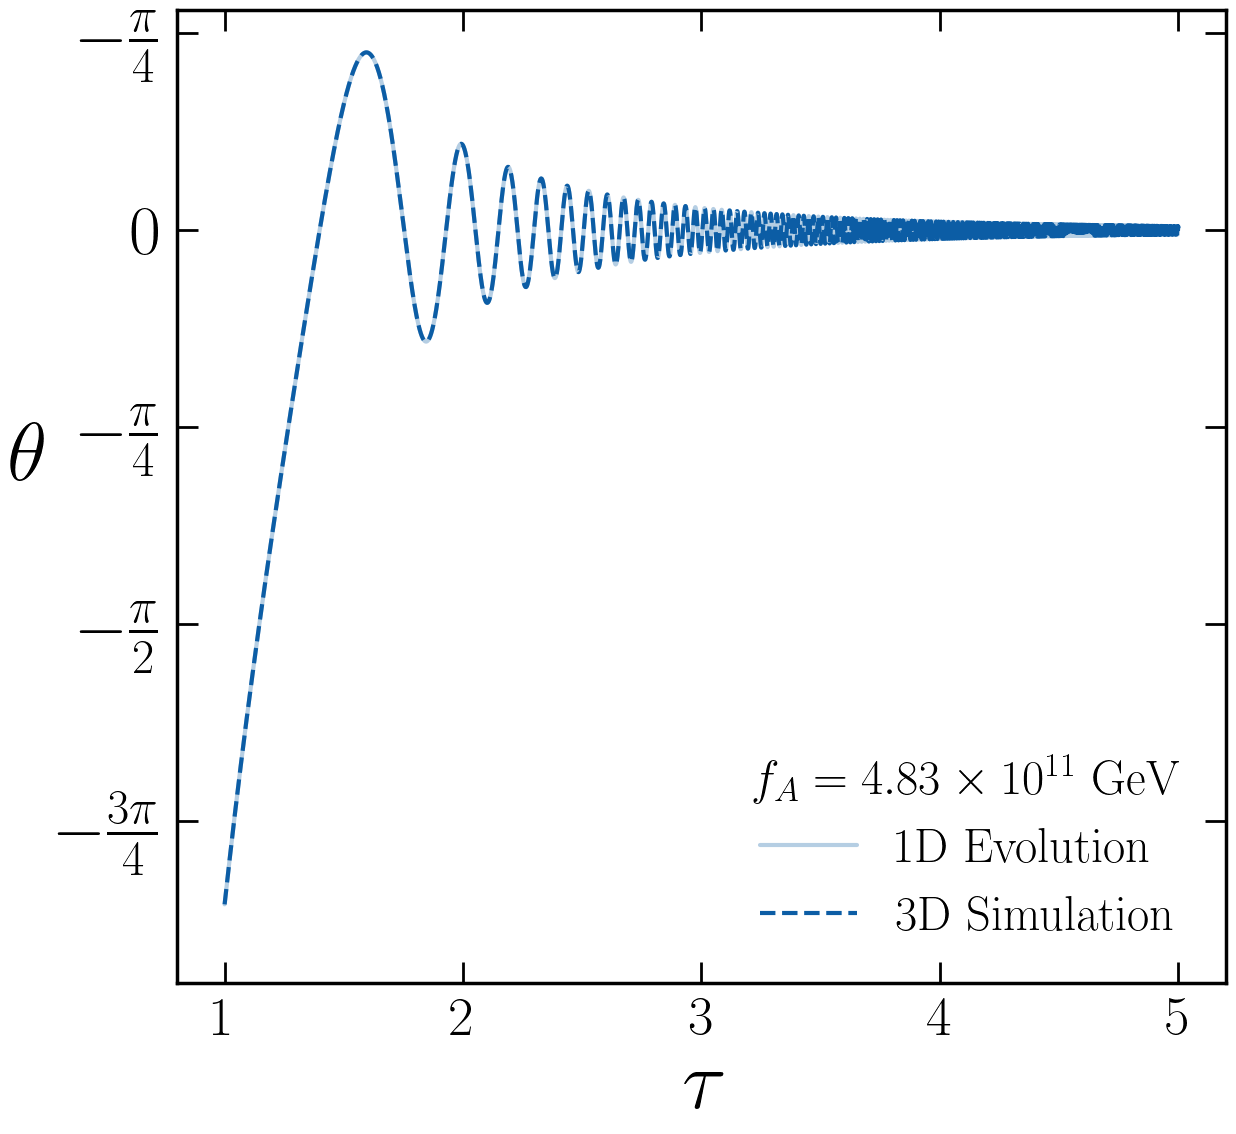

In [3]:
plt.figure()#figsize=(21,9))


p = plt.plot(τ,θ, label = '1D Evolution',alpha = 0.3)

#Add corresponding 3D curve
plt.plot(τ,θ, label = '3D Simulation', ls = 'dashed', color = p[0].get_color())

plt.xlabel(r'$\tau$', size = 60)
plt.ylabel(r'$\theta$', rotation=0, labelpad=20, size = 60)

plt.xticks(fontsize=40)
plt.yticks([-np.pi, -3*np.pi/4,- np.pi/2,- np.pi/4, 0, np.pi/4], [r'$-\pi$', r'$-\frac{3\pi}{4}$', r'$-\frac{\pi}{2}$', r'$-\frac{\pi}{4}$', '0', r'$-\frac{\pi}{4}$'], fontsize = 50)
plt.tick_params(axis='y', pad=10)

plt.ylim(-3,)


plt.legend(loc='lower right', title=r'$f_A= 4.83\times 10^{11}$ GeV')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'theta_evol_fA4.83e11.pdf')

plt.show()

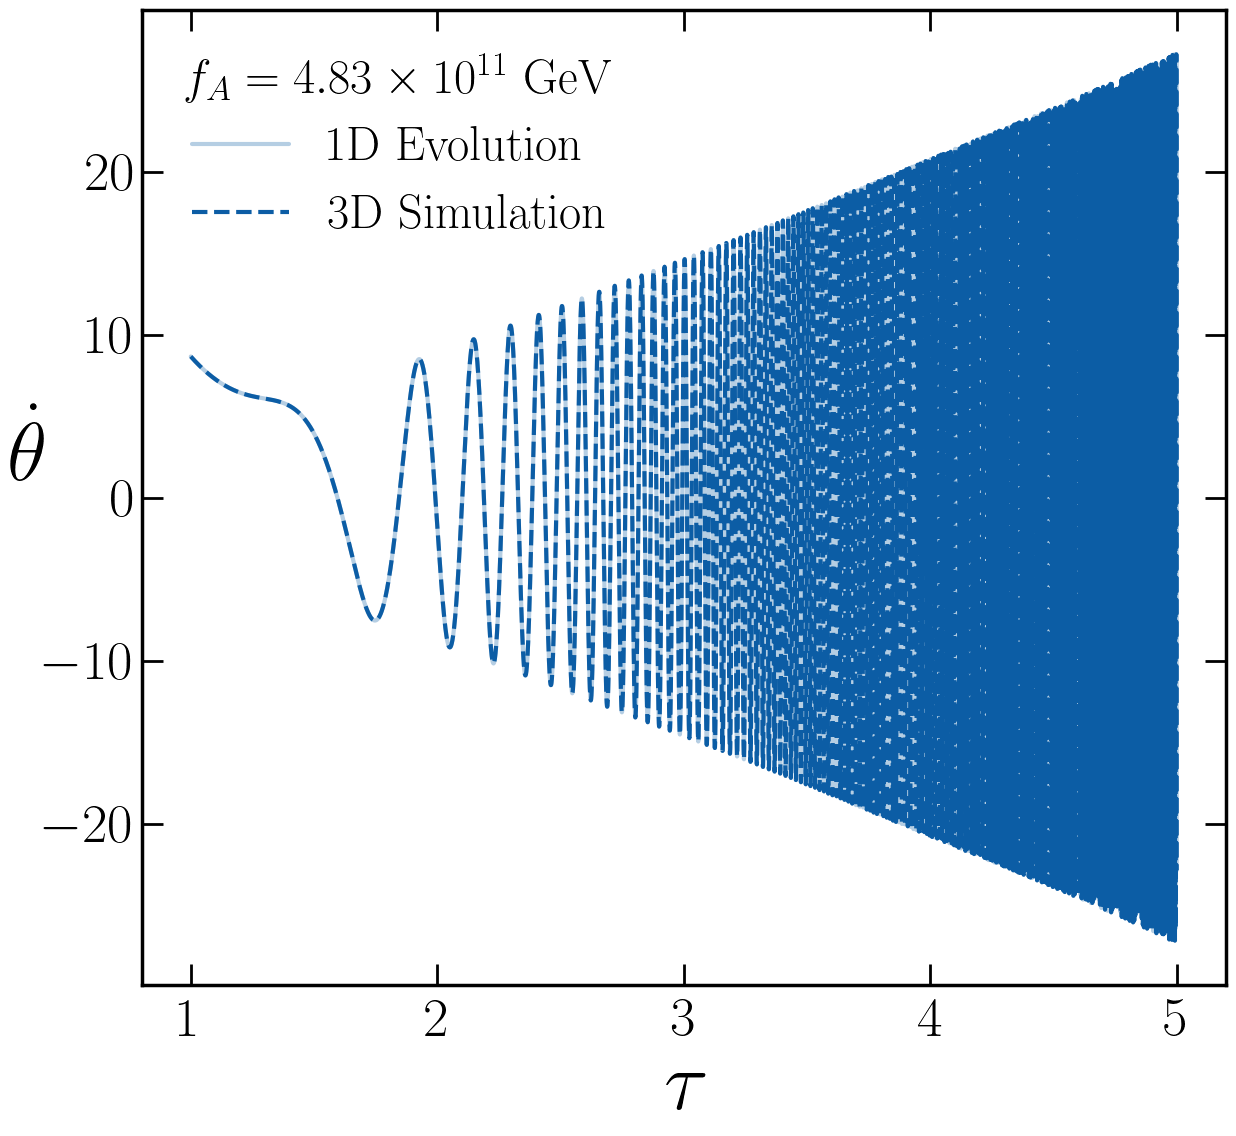

In [5]:
plt.figure()

p = plt.plot(τ,vθ, label = '1D Evolution', alpha = 0.3)
#Add corresponding 3D curve
plt.plot(τ,vθ, label = '3D Simulation', ls = 'dashed', color = p[0].get_color())

plt.xlabel(r'$\tau$', size = 60)
plt.ylabel(r'$\dot{\theta}$', rotation=0, labelpad=10, size = 60)

plt.xticks(fontsize = 40)
plt.yticks(fontsize = 40)

#plt.ylim(-3,)

plt.legend(loc='upper left', title=r'$f_A= 4.83\times 10^{11}$ GeV')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'vheta_evol_fA4.83e11.pdf')

plt.show()

## Slices
To visualize the initial field distribution, axitons etc. Not sure if it will end up in the actual paper.

## Parameter Matches
Plot that shows the closed curves for our discussion of the fact that there are many solutions etc. Add plot of the fit for the max velocity constellations that Mathieu worked on. 


NOT HAPPY WITH THIS PLOT!!


In [6]:
fAs = np.array([5e10, 1e11, 5e11, 1e12, 5e12])

θ_matches = np.load(DATA_DIR + 'param_matches_theta.npy', allow_pickle = True)
vθ_matches = np.load(DATA_DIR + 'param_matches_vheta.npy', allow_pickle = True)

labels = [r'$5\times 10^{10}$ GeV', r'$1\times 10^{11}$ GeV', r'$5\times 10^{11}$ GeV', r'$1\times 10^{12}$ GeV', r'$5\times 10^{12}$ GeV']

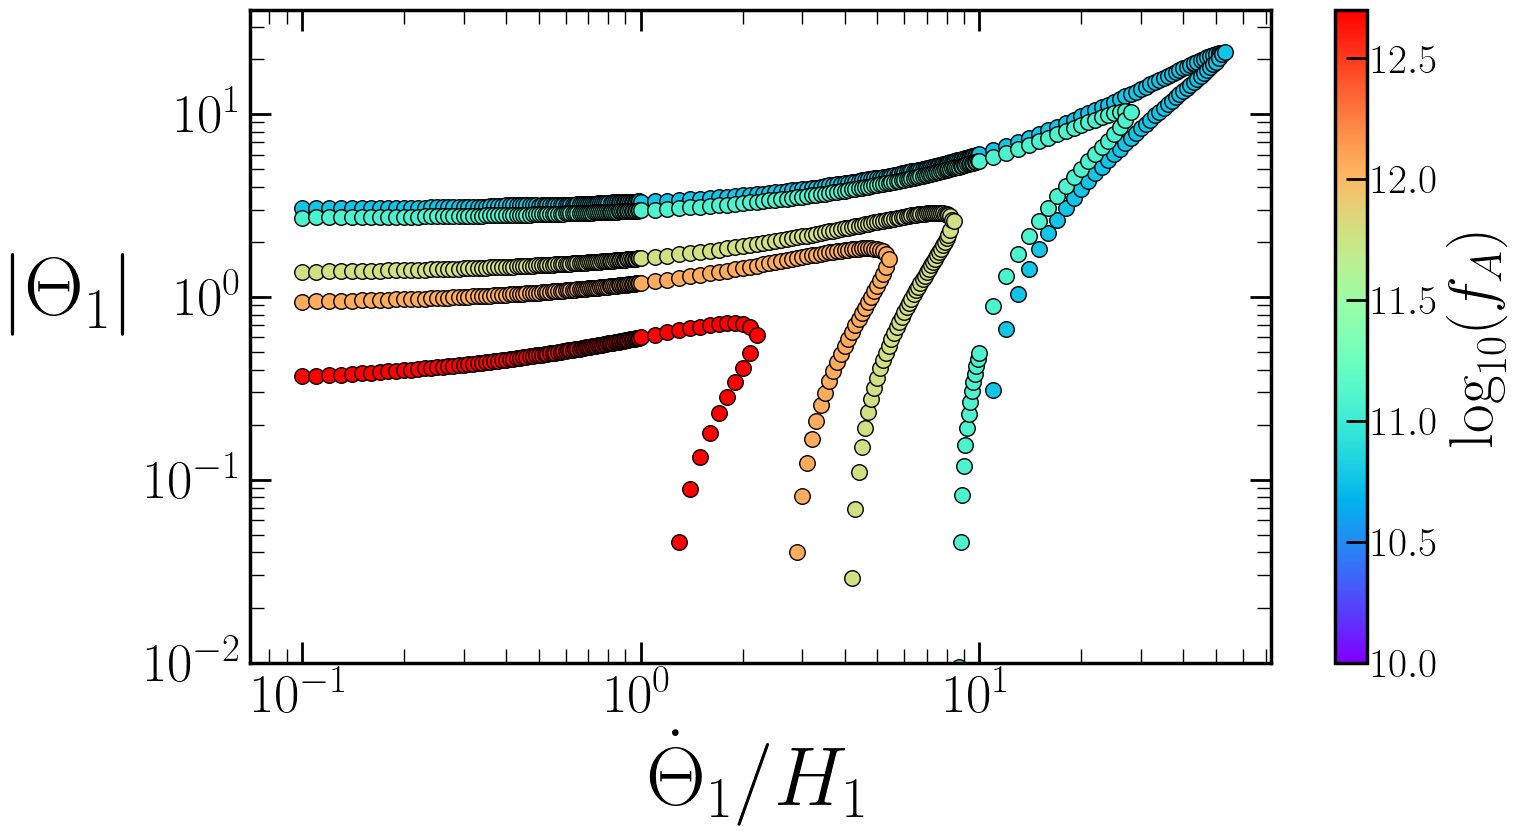

In [11]:
fig, ax = plt.subplots(figsize=(16,9))

# Define colormap and normalization
cmap = cm.rainbow
vmin=np.log10(1e10)
vmax=np.log10(5e12)   # fixed color limits
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) 

for id, v in enumerate(vθ_matches):
    ax.scatter(v, -θ_matches[id], label = r'$f_A =$ %s'%labels[id], s= 500, marker = '.', color = cmap(norm(np.log10(fAs[id]))), edgecolor='k')

plt.colorbar(sc, ax=ax, label=r'$\log_{10}(f_A)$')

    

plt.xlabel(r'$\dot{\Theta}_1/H_1$', size = 60)
plt.ylabel(r'$|\Theta_1|$', size = 60, rotation = 0, labelpad = 50)

plt.xscale('log')
plt.yscale('log')

plt.xticks(fontsize = 40)
plt.yticks(fontsize = 40)
##plt.yticks([-8*np.pi, -6*np.pi, -4*np.pi, -2*np.pi, -np.pi, 0, np.pi],
#           [r'$-8\pi$', r'$-6\pi$', r'$-4\pi$', r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$'])

plt.xlim(7e-2,)
plt.ylim(1e-2,)

#plt.legend(loc = 'upper center', ncol=2, fontsize = 35)#, title=r'$f_A$')

plt.tight_layout()
plt.savefig(PLOT_DIR + 'parameter_matches.pdf')

plt.show()

### Tips = maximum velocity

In [8]:
fAs_full, vheta_full, theta_full_shifted = np.loadtxt(DATA_DIR + 'tips_theta_shifted.txt', unpack = True)

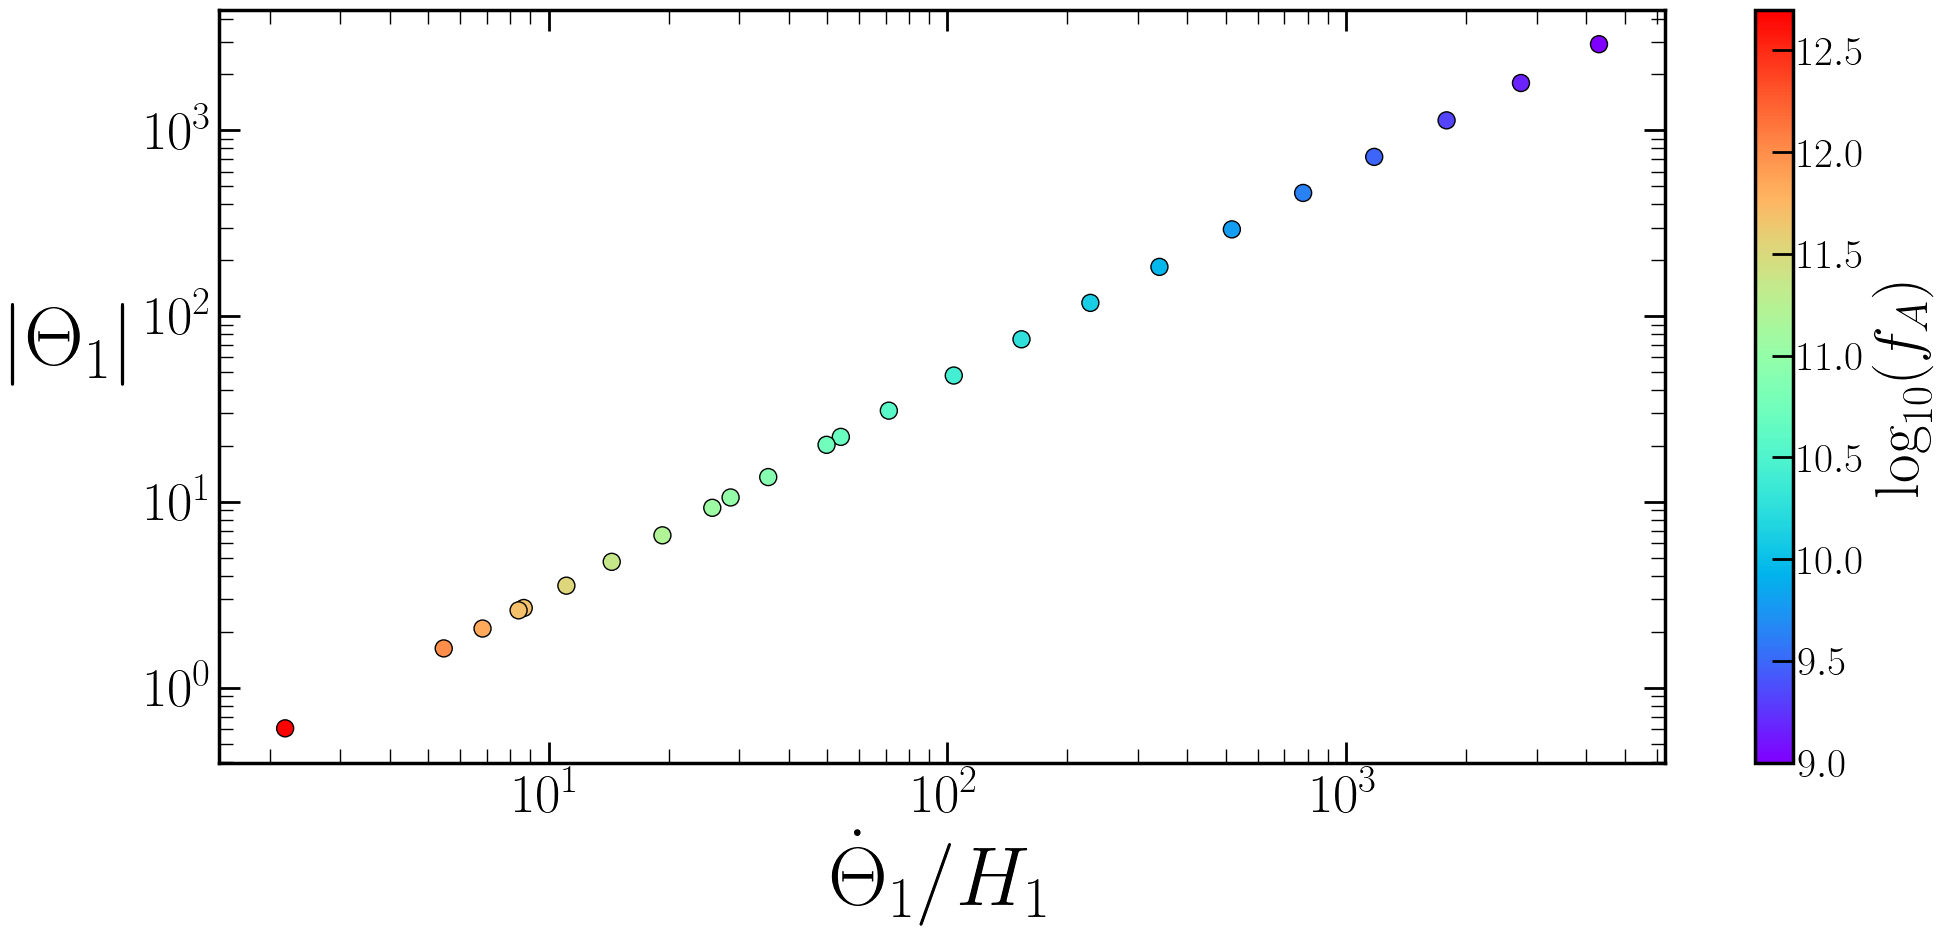

In [13]:
# Now your original plotting code works exactly as before:
plt.figure(figsize=(21,10))

# scatter tip data
sc = plt.scatter(vheta_full, -theta_full_shifted, s=150, c=np.log10(fAs_full), cmap='rainbow', 
                edgecolor='k', label='Tips (Data)', zorder=10,
                vmin=9, vmax=np.log10(5e12))


#plt.scatter(vheta_kirthi, theta_kirthi, s=150, color='k', label='Tips (Data)', zorder=10)

#plt.plot(x_range, A*x_range**k, 'k--')

plt.colorbar(sc, label=r'$\log_{10}(f_A)$')

plt.xlabel(r'$\dot{\Theta}_1/H_1$', size = 60)
plt.ylabel(r'$|\Theta_1|$', size = 60, rotation = 0, labelpad = 50)

plt.xscale('log')
plt.yscale('log')

plt.xticks(fontsize = 40)
plt.yticks(fontsize = 40)

#plt.xlim(1e0, 7e3)
#plt.ylim(-2*np.pi, 0*np.pi)
#plt.ylim(-15*np.pi, np.pi)

#plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(PLOT_DIR + 'vmax_params.pdf')
            
plt.show()

DISCUSS FITS!

## Single Mode -- Temporal Evolution

## Power Spectra 
Probably the main result of this work, maybe we can compare to the what the recent paper plotted.

In [ ]:
## Save data on bonden or so to txt files

## Misc (Parameter space etc.)
Maybe we can have a nice exclusion plot or similar, just a basic setup for now. 

In [14]:
sys.path.append('/Users/Mathieu/Documents/GitHub/AxionLimits/')
from PlotFuncs import BlackHoleSpins, Axion_fa, MySaveFig, FigSetup, line_background, UpperFrequencyAxis_Simple, AlternativeCouplingAxis, FilledLimit

Text(1.5e-19, 1e-19, '{\\bf SMBH spins}')

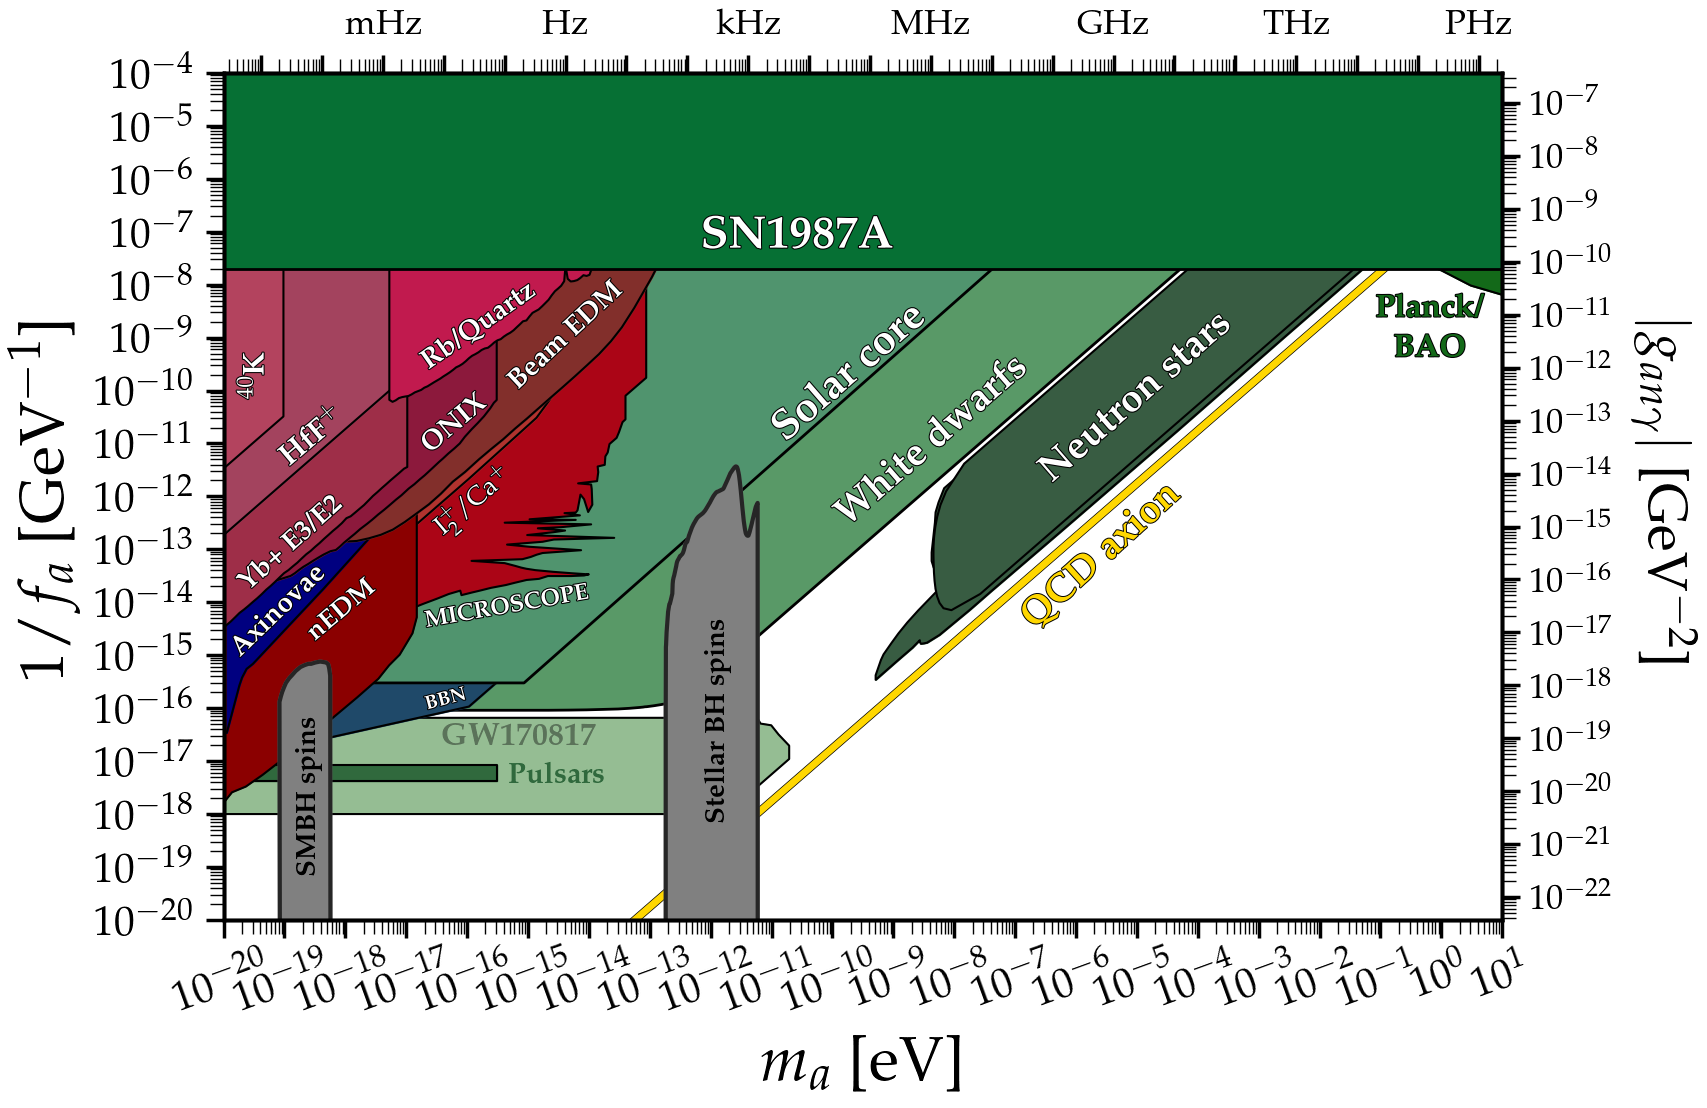

In [220]:
os.chdir('/Users/Mathieu/Documents/GitHub/AxionLimits/')

fig,ax = FigSetup(Shape='Rectangular',ylab=r'$1/f_a$ [GeV$^{-1}$]',mathpazo=True,\
                              g_min=1e-20,g_max=1e-4,m_min=1e-20,m_max=10)
UpperFrequencyAxis_Simple(ax)
AlternativeCouplingAxis(ax,scale=3.7e-3,ylabel=r'$|g_{an\gamma}|$ [GeV$^{-2}$]')

BlackHoleSpins(ax,1,[4e-11,1e-17],fs=27,whichfile='Hoof',rotation=-90,text_col='w',alpha=1,facecolor='gray',text_on=False,zorder=0.1)
BlackHoleSpins(ax,1,[4e-11,1e-17],fs=27,whichfile='Witte',rotation=-90,text_col='w',alpha=1,facecolor='gray',text_on=False,zorder=0.1)
#BlackHoleSpins(ax,1,[4e-11*(1+0.01),1e-17*(1+0.02)],fs=27,whichfile='Baryakhtar',rotation=-90,text_col='k',alpha=1,facecolor='darkgray',text_on=True)
#BlackHoleSpins(ax,1,[4e-11*(1+0.01),1e-17*(1+0.02)],fs=27,whichfile='Unal',rotation=-90,text_col='k',alpha=1,facecolor='lightgray',text_on=False,zorder=0.05)


Axion_fa.QCDAxion(ax)
Axion_fa.nEDM(ax)
Axion_fa.BeamEDM(ax)
Axion_fa.HfF(ax)
Axion_fa.I2Ca(ax)
Axion_fa.RbQuartz(ax)
Axion_fa.ONIX(ax)
Axion_fa.K40(ax)
Axion_fa.Yb(ax)
Axion_fa.SolarCore(ax)
Axion_fa.WhiteDwarfs(ax)
Axion_fa.Pulsars(ax)
Axion_fa.SN1987A(ax)
Axion_fa.GW170817(ax)
Axion_fa.BBN(ax)
Axion_fa.PlanckBAO(ax)
Axion_fa.Axinovae(ax)
Axion_fa.NeutronStars(ax)
Axion_fa.MICROSCOPE(ax)

plt.text(0.8e-12,1e-18,r'{\bf Stellar BH spins}',fontsize=20,rotation=90)
plt.text(1.5e-19,0.1e-18,r'{\bf SMBH spins}',fontsize=20,rotation=90)


#MySaveFig(fig,'Axion_fa')

### We can also make this ourselves: 

In [16]:
os.chdir('/Users/Mathieu/Desktop/Current Stuff/Kinetic Misalignment/kinetic-misalignment/analysis')

#Get Limits from Ciarans repo
AXION_LIMITS = '/Users/Mathieu/Documents/GitHub/AxionLimits/limit_data/fa/'  #path to Ciarans Git Repo (keep updated)

#SN1987
x_SN, y_SN = np.loadtxt(AXION_LIMITS + 'SN1987A.txt', comments='#', unpack = True)

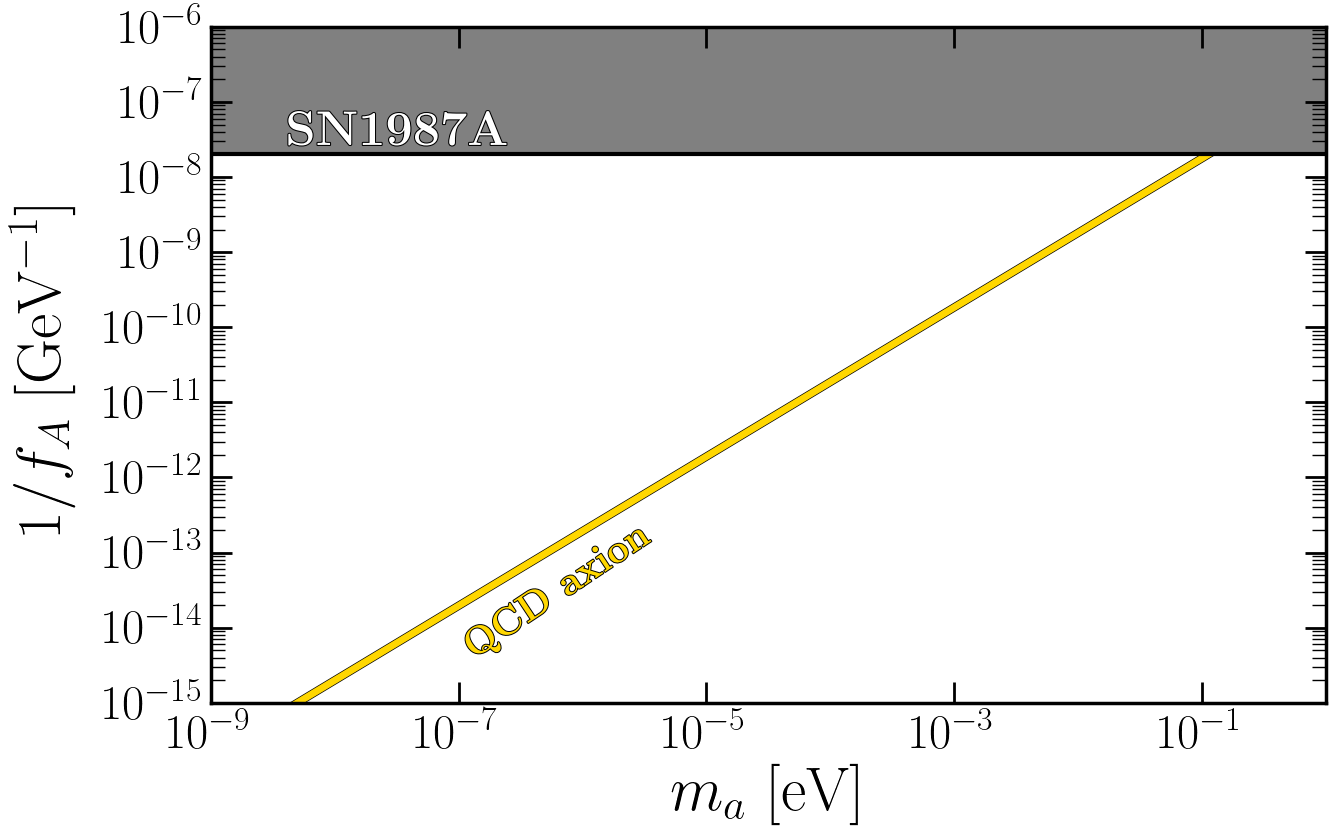

In [20]:
# Plot the exclusion region using a filled contour plot
fig, ax = plt.subplots(figsize=(14, 9))

#Add QCD Axion Line
Axion_fa.QCDAxion(ax)

#plt.plot(mass, excl, color = 'k', lw = 2, zorder = 100)
#plt.fill_between(mass, excl, np.ones(len(mass)), color = 'darkred', alpha = 1.)


#Existing bounds
plt.fill_between(x_SN, y_SN, np.ones(len(x_SN)), color = 'gray')
plt.plot(x_SN, y_SN, color = 'k')
plt.text(4e-9, y_SN[1], r'$\mathbf{SN1987A}$', color = 'w', fontsize = 35, ha='left',va='bottom', zorder = 50,clip_on=True, path_effects=line_background(1.5,'k'))
#plt.fill_between(m_a, IAXO_2021*np.ones(len(m_a)), CUORE_2015*np.ones(len(m_a)), color = '#4A98A0', alpha = 0.3)

#plt.plot(m_a, CAST_2009*np.ones(len(m_a)), color = 'k', ls = 'dashed', lw = 2)
#plt.plot(m_a, CUORE_2015*np.ones(len(m_a)), color = 'k', lw = 2)
#plt.plot(m_a, BabyIAXO_2021_opt*np.ones(len(m_a)), color = 'k', lw = 2)
#plt.plot(m_a, IAXO_2021*np.ones(len(m_a)), color = 'k', lw = 2)


#plt.text(2e-15, 0.88*CUORE_2015, r'$\mathbf{CUORE}\ (^{57}\mathrm{Fe}$)', color = 'w', fontsize = fs, ha='left',va='top', zorder = 50)#,clip_on=True, path_effects=line_background(1.5,'k')
#plt.text(2e-15, BabyIAXO_2021_opt, r'$\mathbf{BabyIAXO}$', color = 'w', fontsize = fs, ha='left',va='bottom', zorder = 50)#,clip_on=True, path_effects=line_background(1.5,'k')
#plt.text(2e-15, IAXO_2021, r'$\mathbf{IAXO}$', color = 'w', fontsize = fs, ha='left',va='bottom', zorder = 50)#,clip_on=True, path_effects=line_background(1.5,'k')

#Astro combined
#plt.plot(m_a, astro_bounds, color = 'k', lw = 2, ls = '-')
#plt.fill_between(m_a, astro_bounds, np.ones(len(astro_bounds)), color = 'lightgray', alpha = 0.5, zorder = -1)
#plt.text(2e-15, 1.1*astro_bounds[0], 'Astrophysics', color = 'k', fontsize = 25, ha='left',va='bottom')



plt.xlim(1e-9, 1e-0)
plt.ylim(1e-15, 1e-6)


plt.xscale('log')
plt.yscale('log')

ax = plt.gca()  # Get current axes

# Set major ticks at every order of magnitude
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, subs=[1.0], numticks=10))
# Set minor ticks at subdivisions within each order of magnitude
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

# Ensure the ticks are visible
ax.yaxis.set_minor_formatter(ticker.NullFormatter())  # Optional: hides minor tick labels


plt.xlabel(r'$m_a$ [eV]')
plt.ylabel(r'$1/f_A$ [GeV$^{-1}$]', labelpad = 20)

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)

# Adjust layout and show the plot
plt.tight_layout()
plt.savefig(PLOT_DIR + 'parameter_space.pdf')
plt.show()